# 01 - EDA et Nettoyage

Analyse exploratoire des données (EDA) et nettoyage du jeu de données `data/raw/car-price.csv`.

## 1. Import des bibliothèques

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Chargement des données

In [11]:
df = pd.read_csv("../data/raw/car-price.csv").reset_index()
df.head()

,index,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,0,Maruti 800 AC,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner
1,1,Maruti Wagon R LXI Minor,2007.0,135000,50000.0,Petrol,Individual,Manual,NaN
2,2,Hyundai Verna 1.6 SX,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner
3,3,Datsun RediGO T Option,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner
4,4,Honda Amaze VX i-DTEC,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          4340 non-null   int64  
 1   name           4340 non-null   str    
 2   year           4297 non-null   float64
 3   selling_price  4340 non-null   int64  
 4   km_driven      4167 non-null   float64
 5   fuel           4254 non-null   str    
 6   seller_type    4275 non-null   str    
 7   transmission   4340 non-null   str    
 8   owner          4254 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 548.6 KB


In [13]:
df.describe()

,index,year,selling_price,km_driven
count,4340.000000,4297.000000,4.340000e+03,4167.000000
mean,2169.500000,2013.087736,5.041273e+05,66237.198224
std,1252.994413,4.219918,5.785487e+05,46635.456187
min,0.000000,1992.000000,2.000000e+04,1.000000
25%,1084.750000,2011.000000,2.087498e+05,35000.000000
50%,2169.500000,2014.000000,3.500000e+05,60000.000000
75%,3254.250000,2016.000000,6.000000e+05,90000.000000
max,4339.000000,2020.000000,8.900000e+06,806599.000000


## 3. Nettoyage des données

### 3.1 Suppression des doublons

In [19]:
nb_dup = df.duplicated().sum()
if nb_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"{nb_dup} de doublons dropped")
else:
    print("aucun doublons trouvés")

aucun doublons trouvés


### 3.2 Gestion des valeurs nulles

In [29]:
# valeur manquante par colonne
print(df.isnull().sum()) 

# ligne avec nan 
ligne_avec_nan = df[df.isnull().any(axis=1)]
# ligne_avec_nan (verification post_traitement done)

index            0
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


### 3.3 imputation par mediane


In [26]:
mediane_year = df['year'].median()
df['year'] = df['year'].fillna(mediane_year)

medianne_km_driven = df['km_driven'].median()
df['km_driven'] = df['km_driven'].fillna(medianne_km_driven)

### 3.4 imputation par mode

In [27]:
# pour les colonnes textuels ou catégoriels

fuel_mode = df['fuel'].mode()[0]
df['fuel'] = df['fuel'].fillna(fuel_mode)

seller_type_mode = df['seller_type'].mode()[0]
df['seller_type'] = df['seller_type'].fillna(seller_type_mode)

owner_mode = df['owner'].mode()[0]
df['owner'] = df['owner'].fillna(owner_mode)

### 3.5 Vérification post-traitement qu'il reste 0 valeur manquante dans le dataframe.

## 4. Visualisation (EDA)

### 4.1 Distribution de `selling_price` et `km_driven`

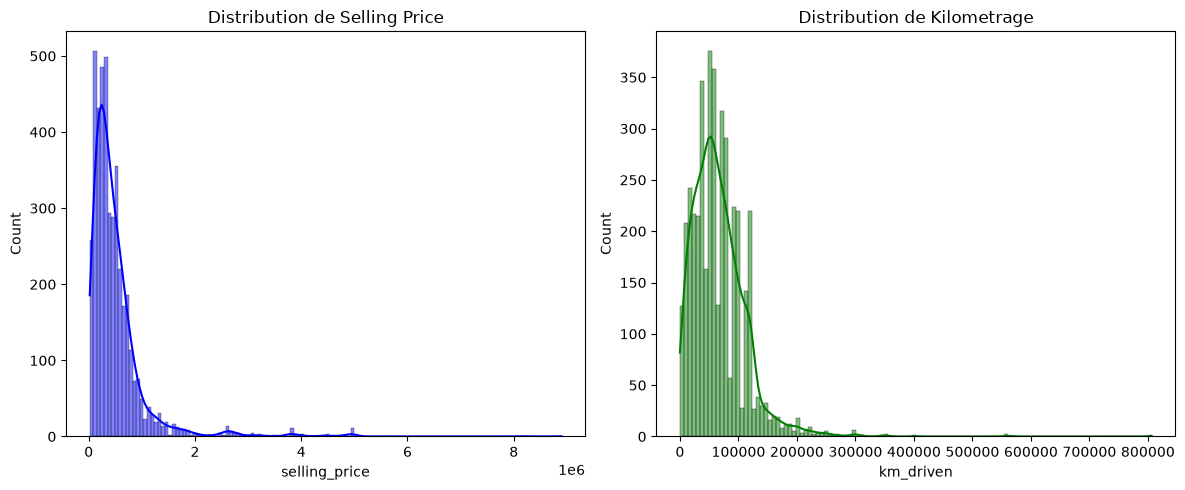

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['selling_price'], kde=True, color='blue')
plt.title('Distribution de Selling Price')

plt.subplot(1, 2, 2)
sns.histplot(df['km_driven'], kde=True, color='green')
plt.title('Distribution de Kilometrage')

plt.tight_layout()
plt.savefig('../reports/figures/distributions.png')
plt.show()

### 4.2 Matrice de corrélation

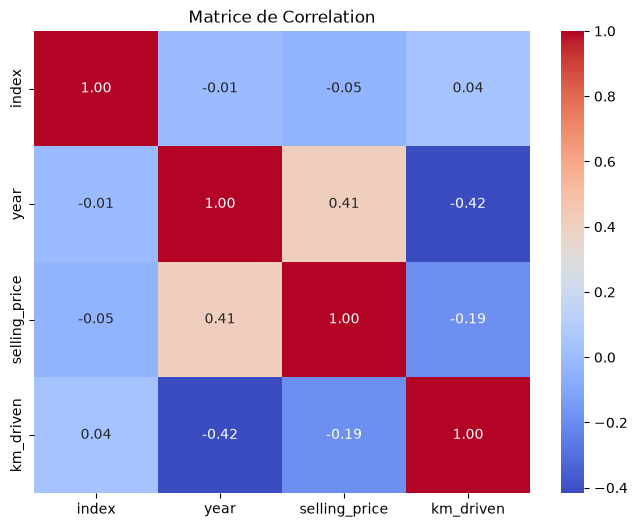

In [17]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Correlation')
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()

### 4.3 Pairplot

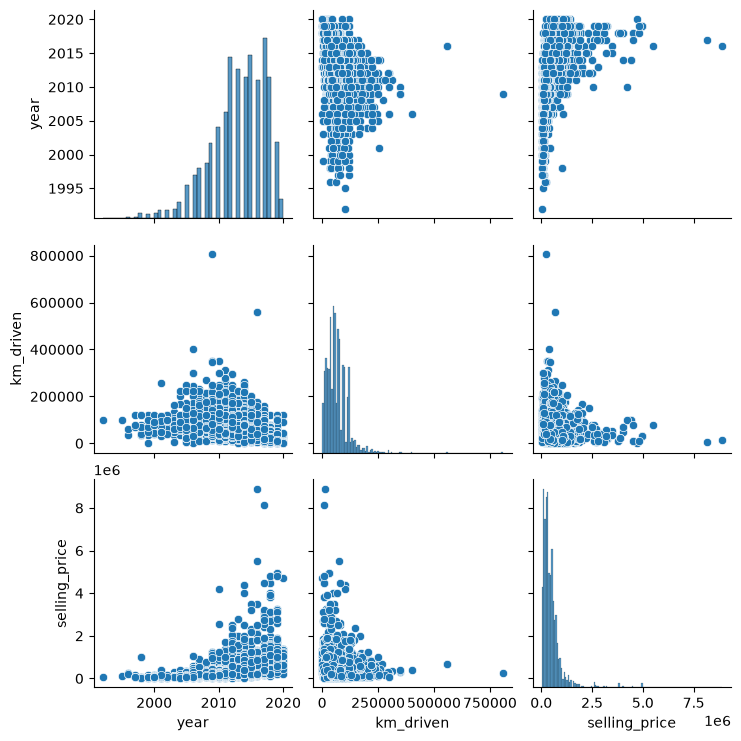

In [18]:
sns.pairplot(df[['year', 'km_driven', 'selling_price']])
plt.savefig('../reports/figures/pairplots.png')
plt.show()

#  5. Detection de valeurs aberrantes

### 5.1 Représentation des variables via des boîtes à moustaches (boxplots).

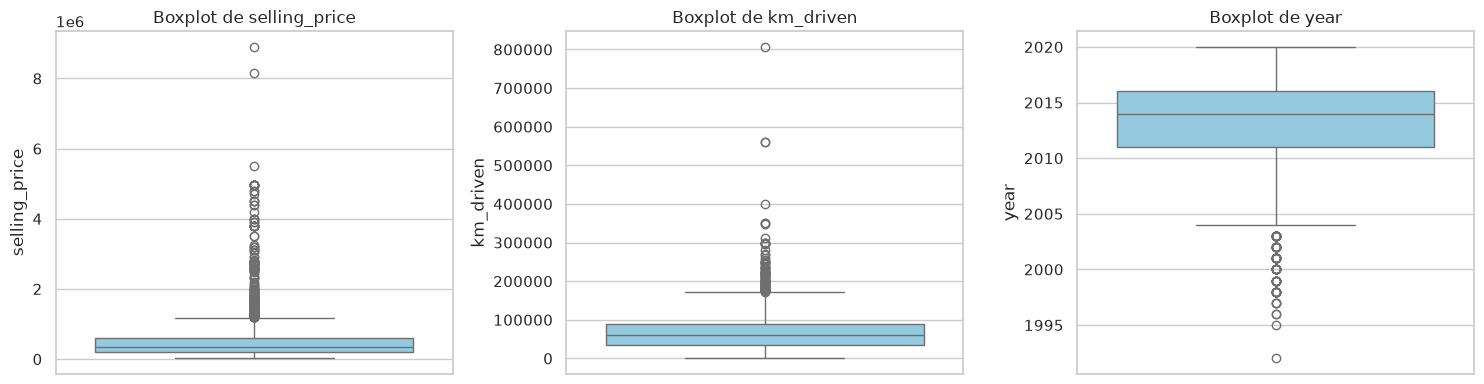

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
cols_outliers = ['selling_price', 'km_driven', 'year']

plt.figure(figsize=(15, 4))
for i, col in enumerate(cols_outliers, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()


### 5.2 Application d'une méthode de détection (Méthode IQR ou Z-score > 3).

In [36]:
def detect_outliers_iqr(dataFrame, column):
    Q1  =dataFrame[column].quantile(0.25)
    Q3  =dataFrame[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5  * IQR
    upper_bound = Q3 + 1.5  * IQR

    outliers = dataFrame[(dataFrame[column] < lower_bound) | (dataFrame[column] > upper_bound)]
    print(f"---------- {column} ----------")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Borne inférieure: {lower_bound:.2f}, Borne supérieure: {upper_bound:.2f}")
    print(f"Nombre d'outliers détectés : {len(outliers)} ({len(outliers)/len(dataFrame)*100:.2f}%)\n")
    
    return lower_bound, upper_bound

### 5.3 Analyse des cas limites et rédaction d'une justification pour chaque action (conservation, correction ou suppression).

In [ ]:
bornes = {}

for col in cols_outliers:
    bornes[col] = detect_outliers_iqr(df, col)
print(bornes)

# ==============================================================================
# JUSTIFICATION DU TRAITEMENT DES OUTLIERS
# ==============================================================================

# 1. selling_price (Variable Cible)
# - Analyse       : Les prix très élevés désignent des véhicules de luxe ou récents.
# - Action        : Plafonnement (Capping) à la borne haute.
# - Justification : Conserve les lignes d'entrée sans supprimer les voitures chères, 
#                   évitant ainsi de biaiser l'apprentissage.

# 2. km_driven (Prédicteur)
# - Analyse       : Présence de kilométrages extrêmes ou d'erreurs de saisie (> 300 000 km).
# - Action        : Plafonnement (Capping) à la borne supérieure.
# - Justification : Élimine le bruit et évite de déformer la pente de régression.

# 3. year (Prédicteur)
# - Analyse       : Faible volume de véhicules très anciens aux prix très spécifiques.
# - Action        : Suppression des lignes où year < borne inférieure.
# - Justification : Recentre le modèle sur le marché principal des voitures récentes.

---------- selling_price ----------
Q1: 208749.75, Q3: 600000.00, IQR: 808749.75
Borne inférieure: -1004374.88, Borne supérieure: 1813124.62
Nombre d'outliers détectés : 114 (2.63%)

---------- km_driven ----------
Q1: 35000.00, Q3: 90000.00, IQR: 125000.00
Borne inférieure: -152500.00, Borne supérieure: 277500.00
Nombre d'outliers détectés : 15 (0.35%)

---------- year ----------
Q1: 2011.00, Q3: 2016.00, IQR: 4027.00
Borne inférieure: -4029.50, Borne supérieure: 8056.50
Nombre d'outliers détectés : 0 (0.00%)

{'selling_price': (np.float64(-1004374.875), np.float64(1813124.625)), 'km_driven': (np.float64(-152500.0), np.float64(277500.0)), 'year': (np.float64(-4029.5), np.float64(8056.5))}


### 5.4 Nettoyage du dataframe en appliquant les filtres définis.